# End-to-End Portfolio Optimization — GMV with CNN-GARCH

**Goal**: Replace inverse-variance weighting with a full **Global Minimum Variance (GMV)** optimization,
using CNN-GARCH predicted volatilities combined with historical rolling correlations.

## Formula
$$\Sigma(t) = D(t) \cdot \text{Corr}_{90d}(t) \cdot D(t), \quad D(t) = \text{diag}(\sigma_{\text{NN}}(t))$$
$$w(t) = \arg\min_{w} \; w^\top \Sigma(t) w \quad \text{s.t.} \; \sum w_i = 1, \; w_i \geq 0, \; w_i \leq 10\%$$

## Strategies compared
1. **Equal-Weight** (1/N baseline)
2. **Inverse-Variance NN** (from Portfolio.ipynb)
3. **GMV-GARCH** — GARCH(1,1) vols + rolling correlations
4. **GMV-NN** ← new method — CNN-GARCH vols + rolling correlations

Inspired by: *Bongiorno et al. (2025) — End-to-End Large Portfolio Optimization*

In [1]:
from __future__ import annotations
import warnings, sys, time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import cvxpy as cp

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')   # access model.py and data_stocks_WIKI_price.py

from model import HybridGarch
from data_stocks_WIKI_price import get_cleaned_data

print(f'PyTorch {torch.__version__} | NumPy {np.__version__} | cvxpy {cp.__version__}')

PyTorch 2.10.0+cpu | NumPy 2.4.2 | cvxpy 1.8.1


In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
FILE_PATH   = r'C:/Users/karim/OneDrive/Documents/Msc AI/Finance/TP/WIKI_PRICES_212b326a081eacca455e13140d7bb9db.zip'
CHECKPOINT  = r'../finetune_real_zeroaware_r2min1e8_best.pt'
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

WINDOW_SIZE = 90      # rolling window — CNN input & correlation window
N_STOCKS    = 30
TRAIN_RATIO = 0.70
ANNUALIZE   = 252
MAX_WEIGHT  = 0.10    # 10% cap per stock (3 x 1/N for N=30)

print(f'Device : {DEVICE} | Window : {WINDOW_SIZE} | Max weight : {MAX_WEIGHT:.0%}')

Device : cpu | Window : 90 | Max weight : 10%


## 1. Data Loading

In [3]:
returns_df_full = get_cleaned_data(FILE_PATH)
print(f'Full universe : {returns_df_full.shape[0]} days x {returns_df_full.shape[1]} stocks')
print(f'Date range    : {returns_df_full.index[0].date()} -> {returns_df_full.index[-1].date()}')

# Select first N_STOCKS (same as Portfolio.ipynb)
selected   = returns_df_full.columns[:N_STOCKS].tolist()
returns_df = returns_df_full[selected].copy()
print(f'\nPortfolio : {N_STOCKS} stocks -> {selected[:5]} ...')

[get_cleaned_data] Universe after filters : 1338 stocks (price≥$3.0 on 2012-10-04, max consec zeros ≤ 20)
Full universe : 4585 days x 1338 stocks
Date range    : 2000-01-04 -> 2018-03-27

Portfolio : 30 stocks -> ['A', 'AAN', 'AAON', 'AAPL', 'ABAX'] ...


## 2. Train / Test Split

In [4]:
n_total   = len(returns_df)
split_idx = int(TRAIN_RATIO * n_total)
start_t   = max(WINDOW_SIZE, split_idx)

returns_train = returns_df.iloc[:split_idx]
returns_test  = returns_df.iloc[split_idx:]
test_dates    = returns_df.index[start_t:]

returns_arr  = returns_df.values.astype(np.float32)   # [T, N]
train_means  = returns_train.mean().values.astype(np.float32)
train_stds   = returns_train.std(ddof=0).values.astype(np.float32)

print(f'Train : {returns_train.index[0].date()} -> {returns_train.index[-1].date()} ({len(returns_train)} days)')
print(f'Test  : {returns_test.index[0].date()}  -> {returns_test.index[-1].date()}  ({len(returns_test)} days)')
print(f'start_t = {start_t} | test_len = {len(test_dates)}')

Train : 2000-01-04 -> 2012-10-03 (3209 days)
Test  : 2012-10-04  -> 2018-03-27  (1376 days)
start_t = 3209 | test_len = 1376


## 3. Load CNN-GARCH Model

In [5]:
model = HybridGarch(hidden=32, kernel=3, conv_layers=5)
model.load_state_dict(torch.load(CHECKPOINT, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print(f'Model loaded : {sum(p.numel() for p in model.parameters()):,} parameters')

Model loaded : 14,499 parameters


## 4. Volatility Estimation Functions

In [6]:
@torch.no_grad()
def _predict_nn_batch(windows_norm, model, device):
    x = torch.tensor(windows_norm, dtype=torch.float32, device=device).unsqueeze(-1)
    sigma2_norm, _, _, _ = model(x)
    return sigma2_norm.cpu().numpy()


def precompute_sigma2_nn(returns_arr, train_means, train_stds, model, device,
                         window_size, start_t, annualize=252):
    T, N = returns_arr.shape
    sigma2_mat = np.full((T - start_t, N), np.nan)
    eps = 1e-8
    for k, t in enumerate(range(start_t, T)):
        windows = returns_arr[t - window_size:t, :]
        if np.isnan(windows).any():
            continue
        wn = (windows.T - train_means[:, None]) / (train_stds[:, None] + eps)
        s2 = _predict_nn_batch(wn, model, device) * (train_stds + eps) ** 2
        sigma2_mat[k] = np.clip(s2, 1e-10, None) * annualize
    return sigma2_mat


def precompute_sigma2_arch(returns_arr, train_means, split_idx, start_t, annualize=252):
    from arch import arch_model as arch_fit
    T, N = returns_arr.shape
    sigma2_mat = np.zeros((T - start_t, N))
    for j in range(N):
        r_j = returns_arr[:split_idx, j].astype(np.float64)
        try:
            res = arch_fit(r_j * 100, mean='Zero', vol='GARCH', p=1, q=1).fit(disp='off')
            omega = res.params['omega'] / 1e4
            alpha = res.params['alpha[1]']
            beta  = res.params['beta[1]']
            s2    = float(res.conditional_volatility[-1] ** 2)
        except Exception:
            omega, alpha, beta = 1e-6, 0.05, 0.90
            s2 = np.var(r_j, ddof=0)
        for t in range(split_idx, T):
            s2 = omega + alpha * returns_arr[t-1, j]**2 + beta * s2
            s2 = max(s2, 1e-10)
            if t >= start_t:
                sigma2_mat[t - start_t, j] = s2 * annualize
    return sigma2_mat


print('Volatility functions defined.')

Volatility functions defined.


## 5. Compute Sigma² Matrices

In [7]:
print('[1/2] CNN-GARCH forward pass...')
t0 = time.time()
sigma2_nn = precompute_sigma2_nn(
    returns_arr, train_means, train_stds, model, DEVICE, WINDOW_SIZE, start_t, ANNUALIZE
)
print(f'      OK ({time.time()-t0:.1f}s)')

print('[2/2] GARCH(1,1) recursion...')
t0 = time.time()
sigma2_arch = precompute_sigma2_arch(
    returns_arr.astype(np.float64), train_means, split_idx, start_t, ANNUALIZE
)
print(f'      OK ({time.time()-t0:.1f}s)')

print(f'\nShape: {sigma2_nn.shape}  [test_days x N_stocks]')

[1/2] CNN-GARCH forward pass...
      OK (8.3s)
[2/2] GARCH(1,1) recursion...
      OK (2.1s)

Shape: (1376, 30)  [test_days x N_stocks]


## 6. GMV Portfolio Optimization

### Rolling Correlation + Covariance Construction

At each day $t$:
$$\Sigma(t) = D(t) \cdot \hat{C}_{t-90:t} \cdot D(t)$$
where $D(t) = \text{diag}(\hat{\sigma}_i(t))$ from CNN-GARCH or GARCH, and $\hat{C}$ is the rolling sample correlation matrix.

In [8]:
def rolling_correlation(returns_arr, t, window_size):
    """Sample correlation matrix from returns[t-window:t]."""
    window = returns_arr[t - window_size:t, :]
    w = window - window.mean(axis=0)
    cov = (w.T @ w) / (window_size - 1)
    std = np.maximum(np.sqrt(np.diag(cov)), 1e-10)
    corr = cov / np.outer(std, std)
    corr = np.clip(corr, -1.0, 1.0)
    np.fill_diagonal(corr, 1.0)
    return corr


def nearest_psd(cov, reg=1e-6):
    """Clip negative eigenvalues → guaranteed PSD."""
    cov = (cov + cov.T) / 2
    eigvals, eigvecs = np.linalg.eigh(cov)
    eigvals = np.maximum(eigvals, reg)
    cov_psd = eigvecs @ np.diag(eigvals) @ eigvecs.T
    return (cov_psd + cov_psd.T) / 2


def build_covariance(sigma2_daily, corr):
    sigma_daily = np.sqrt(np.maximum(sigma2_daily / ANNUALIZE, 1e-10))
    D = np.diag(sigma_daily)
    return nearest_psd(D @ corr @ D)


def gmv_weights(cov, max_weight=0.10):
    """Long-only GMV via Cholesky decomposition.

    w^T Sigma w = ||L^T w||^2  (L = cholesky(Sigma))
    Uses cp.sum_squares — no PSD matrix check, no ArpackNoConvergence.
    """
    N = cov.shape[0]
    cov_psd = nearest_psd(cov)
    try:
        L = np.linalg.cholesky(cov_psd)   # always succeeds after nearest_psd
    except np.linalg.LinAlgError:
        return np.ones(N) / N

    w = cp.Variable(N)
    objective   = cp.Minimize(cp.sum_squares(L.T @ w))   # no quad_form → no PSD check
    constraints = [cp.sum(w) == 1, w >= 0, w <= max_weight]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.CLARABEL)

    if prob.status in ('optimal', 'optimal_inaccurate') and w.value is not None:
        weights = np.maximum(np.array(w.value).flatten(), 0)
        s = weights.sum()
        return weights / s if s > 1e-10 else np.ones(N) / N
    return np.ones(N) / N


print('GMV functions defined  (Cholesky trick — no quad_form PSD check).')

GMV functions defined  (Cholesky trick — no quad_form PSD check).


In [9]:
def compute_gmv_portfolio(sigma2_mat, returns_arr, start_t, window_size,
                          max_weight=0.10, label='GMV'):
    """Compute daily GMV portfolio returns and weights.
    Returns:
        port_returns : [test_len]
        weights_hist : [test_len, N]
    """
    test_len = sigma2_mat.shape[0]
    N        = sigma2_mat.shape[1]
    port_returns = np.zeros(test_len)
    weights_hist = np.zeros((test_len, N))

    for k in range(test_len):
        t    = start_t + k
        r_t  = returns_arr[t]                            # realized return at day t
        s2_k = sigma2_mat[k]                             # predicted sigma2 at day t

        # Handle NaN in sigma2 -> fallback to equal weight
        if np.isnan(s2_k).any():
            w = np.ones(N) / N
        else:
            corr = rolling_correlation(returns_arr, t, window_size)  # [N, N]
            cov  = build_covariance(s2_k, corr)                      # [N, N]
            w    = gmv_weights(cov, max_weight=max_weight)            # [N]

        port_returns[k] = np.dot(w, r_t)
        weights_hist[k] = w

        if k % 200 == 0:
            print(f'  [{label}] Day {k}/{test_len} — max_w={w.max():.1%} HHI={( w**2).sum():.3f}')

    return port_returns, weights_hist


print('compute_gmv_portfolio defined.')

compute_gmv_portfolio defined.


## 7. Run All Strategies

In [10]:
# ── Inverse-Variance NN (baseline from Portfolio.ipynb) ───────────────────────
def inverse_variance_weights(sigma2, eps=1e-10):
    s2 = sigma2.copy()
    nm = np.isnan(s2) | (s2 <= 0)
    if nm.all(): return np.ones(len(s2)) / len(s2)
    s2[nm] = np.nanmean(s2[~nm])
    inv = 1.0 / np.maximum(s2, eps)
    return inv / inv.sum()


def compute_inv_var_portfolio(sigma2_mat, returns_arr, start_t):
    test_len = sigma2_mat.shape[0]
    N        = sigma2_mat.shape[1]
    port_returns = np.zeros(test_len)
    weights_hist = np.zeros((test_len, N))
    for k in range(test_len):
        t = start_t + k
        w = inverse_variance_weights(sigma2_mat[k])
        port_returns[k] = np.dot(w, returns_arr[t])
        weights_hist[k] = w
    return port_returns, weights_hist


print('Computing all strategies...')

# 1. Equal-Weight
N = N_STOCKS
r_eq = np.array([np.dot(np.ones(N)/N, returns_arr[t]) for t in range(start_t, len(returns_arr))])
w_eq = np.tile(np.ones(N)/N, (len(r_eq), 1))
print('  [1/4] Equal-Weight done')

# 2. Inverse-Variance NN
r_inv_nn, w_inv_nn = compute_inv_var_portfolio(sigma2_nn, returns_arr, start_t)
print('  [2/4] Inverse-Variance NN done')

# 3. GMV-GARCH
print('  [3/4] GMV-GARCH...')
t0 = time.time()
r_gmv_arch, w_gmv_arch = compute_gmv_portfolio(
    sigma2_arch, returns_arr, start_t, WINDOW_SIZE, MAX_WEIGHT, label='GMV-GARCH'
)
print(f'        Done ({time.time()-t0:.0f}s)')

# 4. GMV-NN
print('  [4/4] GMV-NN...')
t0 = time.time()
r_gmv_nn, w_gmv_nn = compute_gmv_portfolio(
    sigma2_nn, returns_arr, start_t, WINDOW_SIZE, MAX_WEIGHT, label='GMV-NN'
)
print(f'        Done ({time.time()-t0:.0f}s)')

print('\nAll strategies computed.')

Computing all strategies...
  [1/4] Equal-Weight done
  [2/4] Inverse-Variance NN done
  [3/4] GMV-GARCH...
  [GMV-GARCH] Day 0/1376 — max_w=10.0% HHI=0.088
  [GMV-GARCH] Day 200/1376 — max_w=10.0% HHI=0.088
  [GMV-GARCH] Day 400/1376 — max_w=10.0% HHI=0.088
  [GMV-GARCH] Day 600/1376 — max_w=10.0% HHI=0.085
  [GMV-GARCH] Day 800/1376 — max_w=10.0% HHI=0.086
  [GMV-GARCH] Day 1000/1376 — max_w=10.0% HHI=0.095
  [GMV-GARCH] Day 1200/1376 — max_w=10.0% HHI=0.083
        Done (12s)
  [4/4] GMV-NN...
  [GMV-NN] Day 0/1376 — max_w=10.0% HHI=0.086
  [GMV-NN] Day 200/1376 — max_w=10.0% HHI=0.078
  [GMV-NN] Day 400/1376 — max_w=10.0% HHI=0.085
  [GMV-NN] Day 600/1376 — max_w=10.0% HHI=0.080
  [GMV-NN] Day 800/1376 — max_w=10.0% HHI=0.086
  [GMV-NN] Day 1000/1376 — max_w=10.0% HHI=0.092
  [GMV-NN] Day 1200/1376 — max_w=10.0% HHI=0.084
        Done (13s)

All strategies computed.


## 8. Financial Metrics

In [11]:
def financial_metrics(returns, annualize=252):
    r = pd.Series(returns).dropna()
    ann_ret = r.mean() * annualize
    ann_vol = r.std(ddof=0) * np.sqrt(annualize)
    sharpe  = ann_ret / ann_vol if ann_vol > 1e-10 else np.nan
    cumret  = (1 + r).cumprod()
    max_dd  = float(((cumret - cumret.cummax()) / cumret.cummax()).min())
    calmar  = ann_ret / abs(max_dd) if abs(max_dd) > 1e-10 else np.nan
    hhi     = 0.0   # placeholder
    return {
        'Ann. Return (%)' : round(ann_ret * 100, 2),
        'Ann. Vol (%)'    : round(ann_vol * 100, 2),
        'Sharpe'          : round(sharpe, 4),
        'Max Drawdown (%)': round(max_dd * 100, 2),
        'Calmar'          : round(calmar, 4),
    }


metrics = pd.DataFrame({
    'Equal-Weight'   : financial_metrics(r_eq),
    'Inv-Var NN'     : financial_metrics(r_inv_nn),
    'GMV-GARCH'      : financial_metrics(r_gmv_arch),
    'GMV-NN'         : financial_metrics(r_gmv_nn),
}).T

print('=' * 60)
print('OUT-OF-SAMPLE PERFORMANCE (2012-2018)')
print('=' * 60)
print(metrics.to_string())
print()

# Highlight best per metric
best_vol    = metrics['Ann. Vol (%)'].idxmin()
best_sharpe = metrics['Sharpe'].idxmax()
best_dd     = metrics['Max Drawdown (%)'].idxmax()
print(f'Best Volatility  : {best_vol}')
print(f'Best Sharpe      : {best_sharpe}')
print(f'Best Max Drawdown: {best_dd}')

OUT-OF-SAMPLE PERFORMANCE (2012-2018)
              Ann. Return (%)  Ann. Vol (%)  Sharpe  Max Drawdown (%)  Calmar
Equal-Weight            19.00         14.06  1.3507            -14.65  1.2965
Inv-Var NN              18.94         12.08  1.5687            -13.68  1.3846
GMV-GARCH               16.73         11.45  1.4613            -12.51  1.3368
GMV-NN                  19.19         11.44  1.6781            -12.54  1.5300

Best Volatility  : GMV-NN
Best Sharpe      : GMV-NN
Best Max Drawdown: GMV-GARCH


## 9. Visualizations

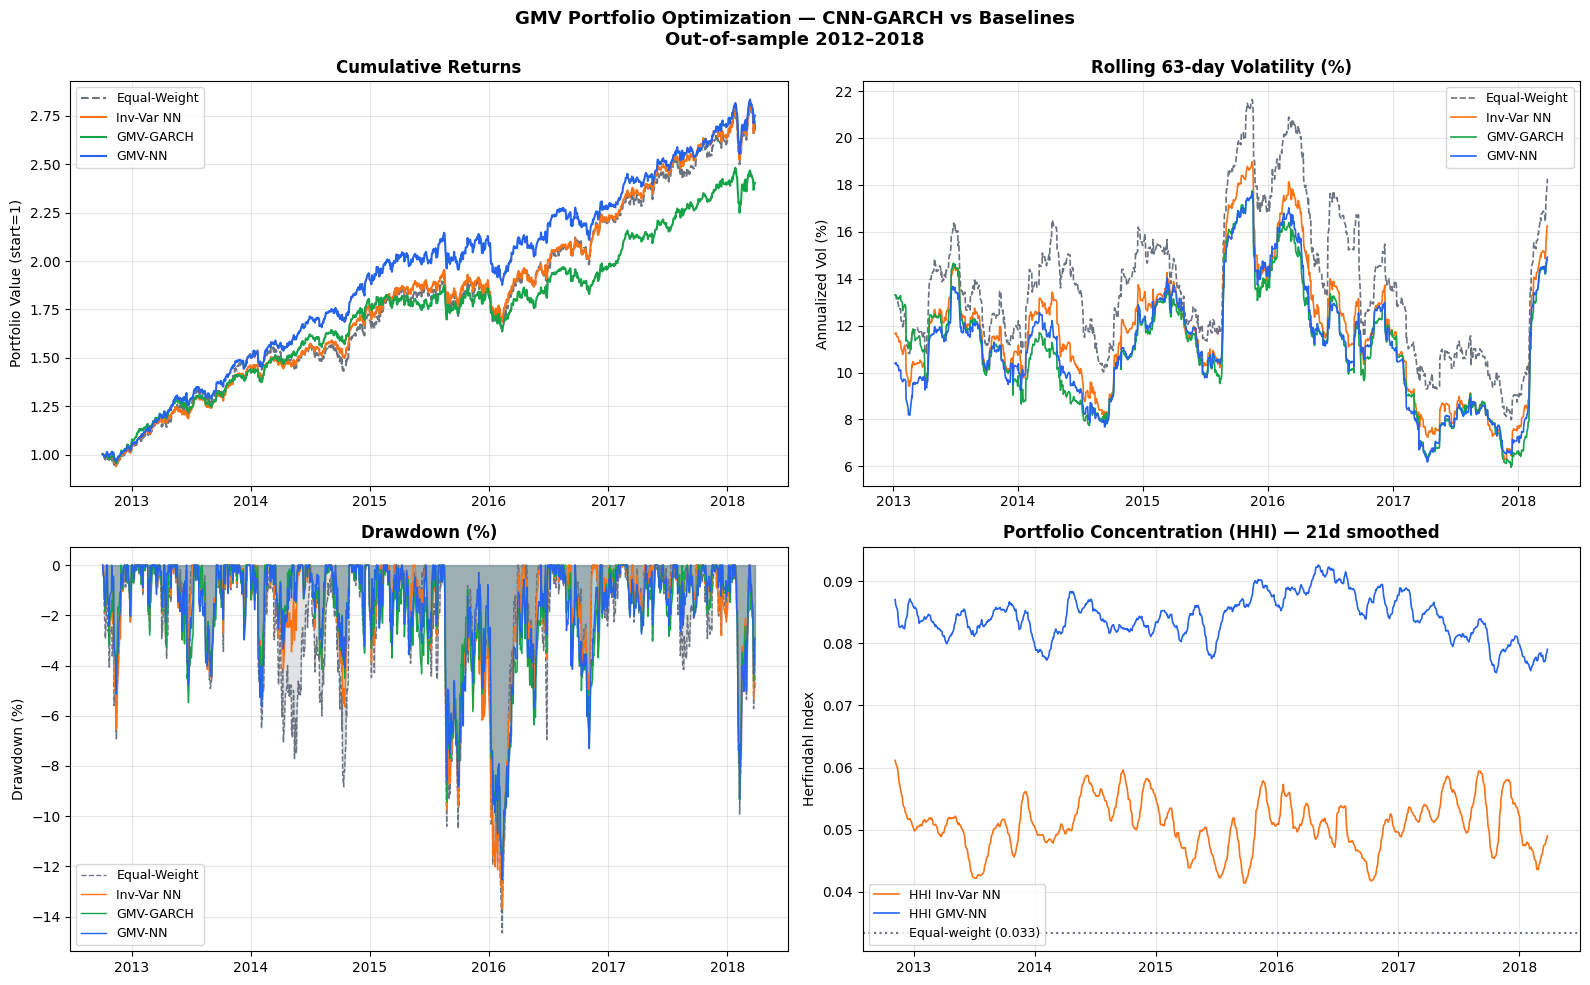

Figure saved: gmv_results.png


In [12]:
# ── Colors ────────────────────────────────────────────────────────────────────
_BLUE   = '#2563EB'
_ORANGE = '#F97316'
_GREEN  = '#16A34A'
_RED    = '#DC2626'
_GREY   = '#6B7280'

strategies = {
    'Equal-Weight' : (r_eq,       _GREY,   '--'),
    'Inv-Var NN'   : (r_inv_nn,   _ORANGE, '-'),
    'GMV-GARCH'    : (r_gmv_arch, _GREEN,  '-'),
    'GMV-NN'       : (r_gmv_nn,   _BLUE,   '-'),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('GMV Portfolio Optimization — CNN-GARCH vs Baselines\nOut-of-sample 2012–2018',
             fontsize=13, fontweight='bold')

# ── 1. Cumulative returns ─────────────────────────────────────────────────────
ax = axes[0, 0]
for name, (r, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    ax.plot(cum.index, cum.values, color=col, linestyle=ls, linewidth=1.5, label=name)
ax.set_title('Cumulative Returns', fontweight='bold')
ax.set_ylabel('Portfolio Value (start=1)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── 2. Rolling 63-day volatility ──────────────────────────────────────────────
ax = axes[0, 1]
for name, (r, col, ls) in strategies.items():
    roll_vol = pd.Series(r, index=test_dates).rolling(63).std() * np.sqrt(252) * 100
    ax.plot(roll_vol.index, roll_vol.values, color=col, linestyle=ls, linewidth=1.2, label=name)
ax.set_title('Rolling 63-day Volatility (%)', fontweight='bold')
ax.set_ylabel('Annualized Vol (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── 3. Drawdown ───────────────────────────────────────────────────────────────
ax = axes[1, 0]
for name, (r, col, ls) in strategies.items():
    cum = (1 + pd.Series(r, index=test_dates)).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd.values, 0, alpha=0.2, color=col)
    ax.plot(dd.index, dd.values, color=col, linestyle=ls, linewidth=1.0, label=name)
ax.set_title('Drawdown (%)', fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── 4. Weight evolution GMV-NN vs Inv-Var NN ─────────────────────────────────
ax = axes[1, 1]
hhi_inv = pd.Series((w_inv_nn**2).sum(axis=1), index=test_dates)
hhi_gmv = pd.Series((w_gmv_nn**2).sum(axis=1), index=test_dates)
ax.plot(hhi_inv.index, hhi_inv.rolling(21).mean(), color=_ORANGE, label='HHI Inv-Var NN', linewidth=1.2)
ax.plot(hhi_gmv.index, hhi_gmv.rolling(21).mean(), color=_BLUE,   label='HHI GMV-NN',    linewidth=1.2)
ax.axhline(1/N_STOCKS, color=_GREY, linestyle=':', label=f'Equal-weight ({1/N_STOCKS:.3f})')
ax.set_title('Portfolio Concentration (HHI) — 21d smoothed', fontweight='bold')
ax.set_ylabel('Herfindahl Index')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gmv_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: gmv_results.png')

In [14]:
N_STOCKS

30

## 10. GMV-NN vs Inv-Var NN — Direct Comparison

In [13]:
# Improvement of GMV-NN over Inv-Var NN
m_inv = financial_metrics(r_inv_nn)
m_gmv = financial_metrics(r_gmv_nn)

print('=== GMV-NN vs Inverse-Variance NN ===')
print(f"{'Metric':<22} {'Inv-Var NN':>12} {'GMV-NN':>12} {'Improvement':>12}")
print('-' * 60)
for k in m_inv:
    v1, v2 = m_inv[k], m_gmv[k]
    if 'Vol' in k or 'Drawdown' in k:
        imp = f'{v1 - v2:+.2f}  ↓ better' if v2 < v1 else f'{v1 - v2:+.2f}'
    else:
        imp = f'{v2 - v1:+.4f}  ↑ better' if v2 > v1 else f'{v2 - v1:+.4f}'
    print(f'{k:<22} {v1:>12} {v2:>12} {imp:>20}')

# Weight concentration
print(f"\n{'Mean HHI Inv-Var NN':<30}: {(w_inv_nn**2).sum(axis=1).mean():.4f}")
print(f"{'Mean HHI GMV-NN':<30}: {(w_gmv_nn**2).sum(axis=1).mean():.4f}")
print(f"{'Max single weight Inv-Var':<30}: {w_inv_nn.max(axis=1).mean():.1%}")
print(f"{'Max single weight GMV-NN':<30}: {w_gmv_nn.max(axis=1).mean():.1%}")

=== GMV-NN vs Inverse-Variance NN ===
Metric                   Inv-Var NN       GMV-NN  Improvement
------------------------------------------------------------
Ann. Return (%)               18.94        19.19    +0.2500  ↑ better
Ann. Vol (%)                  12.08        11.44      +0.64  ↓ better
Sharpe                       1.5687       1.6781    +0.1094  ↑ better
Max Drawdown (%)             -13.68       -12.54                -1.14
Calmar                       1.3846         1.53    +0.1454  ↑ better

Mean HHI Inv-Var NN           : 0.0509
Mean HHI GMV-NN               : 0.0842
Max single weight Inv-Var     : 10.4%
Max single weight GMV-NN      : 10.0%
